In [26]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
threshold = 5
def plot_velocity_hist(pcd, bins: int = 50, range=(-5, 5)):
    vel = np.asarray(pcd[:, 3], dtype=np.float64).ravel()
    vel = vel[np.isfinite(vel)]

    mean = float(vel.mean())
    std = float(vel.std())

    fig, ax = plt.subplots()
    counts, bin_edges, patches = ax.hist(vel, bins=bins, range=range)

    ax.set_xlabel("v_r")
    ax.set_ylabel("Count")

    ax.axvline(mean, linestyle="--", color="red", linewidth=1)
    ymax = ax.get_ylim()[1]
    ax.text(mean, 0.96 * ymax,
            f"mean={mean:.3f}\nstd={std:.3f}",
            ha="center", va="top", color="red")

    ax.set_xticks(bin_edges)
    ax.set_xticklabels([f"{edge:.1f}" for edge in bin_edges], rotation=90, fontsize=8)

    fig.tight_layout()
    plt.show()


def visualize_heat_map(feature_map, channel_index, name):
    heatmap = feature_map[channel_index].detach().cpu().numpy()

    plt.figure(figsize=(20, 5))
    plt.imshow(heatmap, cmap='plasma', interpolation='bilinear')  # softer colors
    plt.colorbar()
    plt.title(name)
    plt.xlabel("W (BEV x)")
    plt.ylabel("H (BEV y)")
    plt.tight_layout()
    plt.show()


def visualize_xy_points(points, title):

    if points.shape[1] >= 2:
        xy = points[:, :2]

    x, y = xy[:, 0], xy[:, 1]

    plt.figure(figsize=(15, 10))
    plt.scatter(x, y, s=0.5, c="blue", alpha=0.6)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    # plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()


def visualize_dynamic_points(points, title):
    # 动态点 (v > 1)
    dynamic_points = points[np.abs(points[:, 3]) > threshold]
    # 静止点 (v <= 1)
    static_points = points[np.abs(points[:, 3]) <= threshold]

    plt.figure(figsize=(15, 5))

    if static_points.size > 0:
        plt.scatter(static_points[:, 0], static_points[:, 1],
                    s=0.5, c="gray", alpha=0.5, label="Static (v≤0.5)")
    if dynamic_points.size > 0:
        plt.scatter(dynamic_points[:, 0], dynamic_points[:, 1],
                    s=0.5, c="red", alpha=0.7, label="Dynamic (v>0.5)")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()
    # plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

def visualize_preprocessed_dynamic_points(points, title):
    # 动态点 (v > 1)
    dynamic_points = points[np.abs(points[:, 3]) > threshold]
    # 静止点 (v <= 1)
    static_points = points[np.abs(points[:, 3]) <= threshold]

    plt.figure(figsize=(15, 5))

    if static_points.size > 0:
        plt.scatter(static_points[:, 0], static_points[:, 1],
                    s=0.5, c="gray", alpha=0.5, label="Static (v≤0.5)")
    if dynamic_points.size > 0:
        plt.scatter(dynamic_points[:, 0], dynamic_points[:, 1],
                    s=0.5, c="red", alpha=0.7, label="Dynamic (v>0.5)")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()



In [27]:
import pickle
from collections import OrderedDict
from typing import Dict
from abc import abstractmethod
import numpy as np
from pypcd import pypcd
import torch
from torch.utils.data import Dataset
from opencood.utils.pcd_utils import shuffle_points, mask_ego_points, downsample_lidar_minimum
from opencood.utils.transformation_utils import x1_to_x2
from opencood.data_utils.pre_processor import build_preprocessor
from opencood.data_utils.post_processor import build_postprocessor
from opencood.utils.pcd_utils import mask_points_by_range


class SingleDatasetLidarRadarBaselineAttentionMlp(Dataset):

    def __init__(self,params: Dict, visualize: bool = False, train: bool = True):
        self.params = params
        self.visualize = visualize
        self.train = train

        #self.save_id = 0

        self.ref_frame = params.get('ref_frame', 'ego_pose') # 'lidar_top_front_pose' or 'ego_pose'

        # Build preprocessors
        # --- LIDAR ----------------------------------------------------------------------------------------------------
        lidar_feature_count = params['preprocess']['args']['lidar_num_point_features']
        lidar_args = {**params['preprocess']['args'], 'num_point_features': lidar_feature_count}
        self.lidar_pre_processor = build_preprocessor({**params['preprocess'], 'args': lidar_args}, train)
        # --------------------------------------------------------------------------------------------------------------

        # --- RADAR ----------------------------------------------------------------------------------------------------
        radar_feature_count = params['preprocess']['args']['radar_num_point_features']
        radar_args = {**params['preprocess']['args'],
                      'max_points_per_voxel': params['preprocess']['args']['radar_max_points_per_voxel'],
                      'max_voxel_train': params['preprocess']['args']['radar_max_voxel_train'],
                      'max_voxel_test': params['preprocess']['args']['radar_max_voxel_test'],
                      'num_point_features': radar_feature_count}
        self.radar_pre_processor = build_preprocessor({**params['preprocess'], 'args': radar_args}, train)
        # --------------------------------------------------------------------------------------------------------------

        self.post_processor = build_postprocessor(params["postprocess"], train)

        self.root_dir = params["root_dir"] if train else params["validate_dir"]
        print("Dataset dir:", self.root_dir)

        self.load_lidar_file = True if 'lidar' in params['input_source'] or self.visualize else False

        self.label_type = params['label_type']
        assert self.label_type in ['lidar']

        self.generate_object_center = self.generate_object_center_lidar
        self.generate_object_center_single = self.generate_object_center

        self.ego_mode = 'one'

        with open(self.root_dir, 'rb') as f:
            dataset_info = pickle.load(f)
        self.dataset_info_pkl = dataset_info

        self.reinitialize()

        self.anchor_box = self.post_processor.generate_anchor_box()
        self.anchor_box_torch = torch.from_numpy(self.anchor_box)

    def reinitialize(self):
        self.scene_database = OrderedDict()
        self.len_record = []

        scene_counter = 0
        total = 0
        for scene_token, samples in self.dataset_info_pkl.items():
            self.scene_database[scene_counter] = OrderedDict()
            for sample_idx, sample in enumerate(samples):
                cav_id = 1
                self.scene_database[scene_counter].setdefault(cav_id, OrderedDict())
                self.scene_database[scene_counter][cav_id][sample_idx] = OrderedDict()

                cav_entry = self.scene_database[scene_counter][cav_id][sample_idx]
                cav_entry['ego'] = True
                cav_entry['sensors'] = sample['agents']['1']['sensors']

                radar_list = [k for k, v in cav_entry['sensors'].items() if v.get('sensor_type') == 'radar']
                lidar_list = [k for k, v in cav_entry['sensors'].items() if v.get('sensor_type') == 'lidar']
                cav_entry['radar_sensors'] = radar_list
                cav_entry['lidar_sensors'] = lidar_list

                cav_entry['params'] = OrderedDict()
                cav_entry['params']['vehicles'] = sample['labels']['gt_boxes_global']
                cav_entry['params']['object_ids'] = sample['labels']['gt_object_ids'].tolist()
                cav_entry['params']['ego_pose'] = sample['agents']['1']['ego_pose']['transform']
                cav_entry['params']['lidar_top_front_pose'] = sample['agents']['1']['lidar_top_front_pose']['transform']
                # cav_entry['params']['ego_speed'] = sample['agents']['1']['ego_motion_chassis']
                cav_entry['params']['ego_speed'] = sample['agents']['1']['ego_motion_cabin']

                total += 1

            scene_counter += 1
            self.len_record.append(total)

    def get_ref_pose(self, cav_params):
        if self.ref_frame == 'lidar_top_front_pose':
            return cav_params['lidar_top_front_pose']
        return cav_params['ego_pose']

    def T_sensor_to_ref(self, sensor_entry, cav_params):
        T_sego = np.asarray(sensor_entry['T_sensor_to_ego'], dtype=np.float64)
        if self.ref_frame == 'ego_pose':
            return T_sego

        ego_pose = np.asarray(cav_params['ego_pose'], dtype=np.float64)
        lidar_pose = np.asarray(cav_params['lidar_top_front_pose'], dtype=np.float64)
        T_ego_to_lidar = x1_to_x2(ego_pose, lidar_pose)
        return T_ego_to_lidar @ T_sego

    def __len__(self):
        return self.len_record[-1]

    @abstractmethod
    def __getitem__(self, idx):
        base_data_dict = self.retrieve_base_data(idx)
        if self.train:
            reformat_data_dict = self.get_item_train(base_data_dict)
        else:
            reformat_data_dict = self.get_item_test(base_data_dict, idx)

        return reformat_data_dict


    def get_item_train(self, base_data_dict):
        processed_data_dict = OrderedDict()

        ego_base = None
        for cav_id, cav_content in base_data_dict.items():
            if cav_content['ego']:
                ego_base = cav_content
                break
        assert ego_base is not None

        selected_cav_processed = self.get_item_single_car(ego_base)

        # No Cars
        if selected_cav_processed is None:
            return None

        processed_data_dict.update({"ego": selected_cav_processed})
        return processed_data_dict


    def get_item_test(self, base_data_dict, idx):
        processed_data_dict = OrderedDict()

        ego_id = -1
        ref_pose = []
        ego_base = None

        for cav_id, cav_content in base_data_dict.items():
            if cav_content['ego']:
                ego_id = cav_id
                ref_pose = self.get_ref_pose(cav_content['params'])
                ego_base = cav_content
                break

        assert ego_id != -1
        assert len(ref_pose) > 0

        transformation_matrix = x1_to_x2(ref_pose, ref_pose)

        ego_processed = self.get_item_single_car(ego_base)

        # No Cars
        if ego_processed is None:
            return None

        ego_processed.update({
            'transformation_matrix': transformation_matrix,
            'idx': idx,
            'cav_list': ['ego']
        })

        processed_data_dict['ego'] = ego_processed
        return processed_data_dict


    def retrieve_base_data(self, idx):

        scene_index = 0
        for i, end_idx in enumerate(self.len_record):
            if idx < end_idx:
                scene_index = i
                break

        sample_index = idx if scene_index == 0 else idx - self.len_record[scene_index - 1]

        ego_cav_id = 1
        cav_content = self.scene_database[scene_index][ego_cav_id][sample_index]

        data = OrderedDict()
        data[f'{ego_cav_id}'] = OrderedDict()
        data[f'{ego_cav_id}']['ego'] = True
        data[f'{ego_cav_id}']['params'] = cav_content['params']

        # --------------------------------------------------------------------------------------------------------------

        # --- RADAR ----------------------------------------------------------------------------------------------------
        radar_points = []
        for sensor_name in cav_content['radar_sensors']:
            s = cav_content['sensors'][sensor_name]


            # --- VELOCITY PROCESSING ----------------------------------------------------------------------------------
            radar_np = self.pcd_to_npy_array(s['sensor_path']) # local coordinate
            radar_transform = np.asarray(s['sensor_pose'])
            lidar_velocity_xyz = np.array([cav_content['params']['ego_speed']['vx'],cav_content['params']['ego_speed']['vy'],cav_content['params']['ego_speed']['vz']])
            ref_vehicle_pose = np.array(self.get_ref_pose(cav_content['params']))

            pts = self.process_all_radar_velocity(radar_np, radar_transform, lidar_velocity_xyz, ref_vehicle_pose)

            # ----------------------------------------------------------------------------------------------------------
            # Sensor -> Ref
            T = self.T_sensor_to_ref(s, cav_content['params'])
            xyz = pts[:, :3]
            xyz_h = np.concatenate([xyz, np.ones((xyz.shape[0], 1))], axis=1)
            xyz_ref = (T @ xyz_h.T).T[:, :3]
            pts[:, :3] = xyz_ref

            radar_points.append(pts)
        # --------------------------------------------------------------------------------------------------------------

        # --- LIDAR ----------------------------------------------------------------------------------------------------
        lidar_points = []
        for sensor_name in cav_content['lidar_sensors']:
            s = cav_content['sensors'][sensor_name]
            pts = self.pcd_to_npy_array_lidar(s['sensor_path'])
            T = self.T_sensor_to_ref(s, cav_content['params'])

            # Sensor -> Ego
            xyz = pts[:, :3]
            xyz_h = np.concatenate([xyz, np.ones((xyz.shape[0], 1))], axis=1)
            xyz_ref= (T @ xyz_h.T).T[:, :3]
            pts[:, :3] = xyz_ref
            lidar_points.append(pts)
        # --------------------------------------------------------------------------------------------------------------
        data[f'{ego_cav_id}']['lidar_np'] = np.vstack(lidar_points)
        data[f'{ego_cav_id}']['radar_np'] = np.vstack(radar_points)

        return data


    def generate_object_center_lidar(self, cav_contents, reference_lidar_pose):
        return self.post_processor.generate_object_center_v2x(cav_contents, reference_lidar_pose)


    def get_item_single_car(self, selected_cav_base):
        selected_cav_processed = {}

        ref_pose = self.get_ref_pose(selected_cav_base['params'])
        object_bbx_center, object_bbx_mask, object_ids = self.generate_object_center_single([selected_cav_base], ref_pose)

        # No Cars
        if len(object_ids) == 0:
            print("No Cars in the scene")
            return None

        # --- LIDAR ----------------------------------------------------------------------------------------------------
        if self.load_lidar_file or self.visualize:
            lidar_np = selected_cav_base['lidar_np']
            lidar_np = shuffle_points(lidar_np)
            lidar_np = mask_points_by_range(lidar_np, self.params['preprocess']['cav_lidar_range'])
            lidar_np = mask_ego_points(lidar_np) # FIXME: check it

            lidar_dict = self.lidar_pre_processor.preprocess(lidar_np)
            selected_cav_processed.update({'processed_lidar': lidar_dict})
        # --------------------------------------------------------------------------------------------------------------

        # --- RADAR ----------------------------------------------------------------------------------------------------
        if self.load_lidar_file or self.visualize:
            radar_np = selected_cav_base['radar_np']
            radar_np = shuffle_points(radar_np)
            radar_np = mask_points_by_range(radar_np, self.params['preprocess']['cav_lidar_range'])
            radar_np = mask_ego_points(radar_np) # FIXME: check it

            ## Speicherpfad zusammensetzen
            #save_path = f"/home/ws-ids-es3-01/PycharmProjects/hamdard_bm2cp/opencood/bilder/{self.save_id}.png"
            #self.save_radar_bev_png(radar_np, save_path)
            #self.save_id += 1  # ID hochzählen

            radar_dict = self.radar_pre_processor.preprocess(radar_np)
            radar_points = radar_dict['voxel_features'].reshape(-1, 7)
            xyz = radar_points[:, :3]
            v = radar_points[:, 5:6]
            xyz_v = np.concatenate([xyz, v], axis=-1)
            visualize_preprocessed_dynamic_points(xyz_v, title="radar")
            selected_cav_processed.update({'processed_radar': radar_dict})



        if self.visualize:
            selected_cav_processed.update({'origin_lidar': lidar_np})

        selected_cav_processed.update(
            {
                "object_bbx_center": object_bbx_center,
                "object_bbx_mask": object_bbx_mask,
                "object_ids": object_ids,
            }
        )

        label_dict = self.post_processor.generate_label(gt_box_center=object_bbx_center, anchors=self.anchor_box, mask=object_bbx_mask)
        selected_cav_processed.update({"label_dict": label_dict})

        return selected_cav_processed


    def collate_batch_train(self, batch):
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None

        output_dict = {'ego': {}}

        object_bbx_center = []
        object_bbx_mask = []
        processed_lidar_list = []
        processed_radar_list = []
        label_dict_list = []
        origin_lidar = []

        for i in range(len(batch)):
            ego_dict = batch[i]['ego']
            object_bbx_center.append(ego_dict['object_bbx_center'])
            object_bbx_mask.append(ego_dict['object_bbx_mask'])
            label_dict_list.append(ego_dict['label_dict'])

            if self.visualize:
                origin_lidar.append(ego_dict['origin_lidar'])

        object_bbx_center = torch.from_numpy(np.array(object_bbx_center))
        object_bbx_mask = torch.from_numpy(np.array(object_bbx_mask))
        label_torch_dict = self.post_processor.collate_batch(label_dict_list)

        # for centerpoint
        label_torch_dict.update({'object_bbx_center': object_bbx_center,
                                 'object_bbx_mask': object_bbx_mask})

        output_dict['ego'].update({'object_bbx_center': object_bbx_center,
                                   'object_bbx_mask': object_bbx_mask,
                                   'anchor_box': torch.from_numpy(self.anchor_box),
                                   'label_dict': label_torch_dict})
        if self.visualize:
            origin_lidar = np.array(downsample_lidar_minimum(pcd_np_list=origin_lidar))
            origin_lidar = torch.from_numpy(origin_lidar)
            output_dict['ego'].update({'origin_lidar': origin_lidar})


        if self.load_lidar_file:
            for i in range(len(batch)):
                processed_lidar_list.append(batch[i]['ego']['processed_lidar'])
            processed_lidar_torch_dict = self.lidar_pre_processor.collate_batch(processed_lidar_list)
            output_dict['ego'].update({'processed_lidar': processed_lidar_torch_dict})

        # --- RADAR ----------------------------------------------------------------------------------------------------
        if self.load_lidar_file:
            for i in range(len(batch)):
                processed_radar_list.append(batch[i]['ego']['processed_radar'])
            processed_radar_torch_dict = self.radar_pre_processor.collate_batch(processed_radar_list)
            output_dict['ego'].update({'processed_radar': processed_radar_torch_dict})

        return output_dict


    def collate_batch_test(self, batch):
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None

        assert len(batch) <= 1, "Batch size 1 is required during testing!"
        batch = batch[0]

        cav_id = 'ego'
        cav_content = batch[cav_id]

        output_dict = {cav_id: {}}

        object_bbx_center = torch.from_numpy(np.array([cav_content['object_bbx_center']]))
        object_bbx_mask = torch.from_numpy(np.array([cav_content['object_bbx_mask']]))
        object_ids = cav_content['object_ids']

        output_dict[cav_id].update({"anchor_box": self.anchor_box_torch})

        if self.load_lidar_file:
            processed_lidar_torch_dict = self.lidar_pre_processor.collate_batch([cav_content['processed_lidar']])
            output_dict[cav_id].update({'processed_lidar': processed_lidar_torch_dict})

        # --- RADAR ----------------------------------------------------------------------------------------------------
        if self.load_lidar_file:
            processed_radar_torch_dict = self.radar_pre_processor.collate_batch([cav_content['processed_radar']])
            output_dict[cav_id].update({'processed_radar': processed_radar_torch_dict})


        label_torch_dict = self.post_processor.collate_batch([cav_content['label_dict']])
        label_torch_dict.update({
            'object_bbx_center': object_bbx_center,
            'object_bbx_mask': object_bbx_mask
        })

        # tm = torch.from_numpy(np.array(cav_content['transformation_matrix'])).float()

        output_dict[cav_id].update({
            'object_bbx_center': object_bbx_center,
            'object_bbx_mask': object_bbx_mask,
            'label_dict': label_torch_dict,
            'object_ids': object_ids,
            # 'transformation_matrix': tm,
        })

        if self.visualize:
            projected_lidar_list = [cav_content['origin_lidar']]
            projected_lidar_stack = [torch.from_numpy(np.vstack(projected_lidar_list))]
            output_dict['ego'].update({'origin_lidar': projected_lidar_stack})

        return output_dict


    def post_process(self, data_dict, output_dict):
        pred_box_tensor, pred_score = self.post_processor.post_process(data_dict, output_dict)
        gt_box_tensor = self.post_processor.generate_gt_bbx(data_dict)

        return pred_box_tensor, pred_score, gt_box_tensor

    def post_process_no_fusion(self, data_dict, output_dict_ego):
        data_dict_ego = OrderedDict()
        data_dict_ego["ego"] = data_dict["ego"]
        gt_box_tensor = self.post_processor.generate_gt_bbx(data_dict)

        pred_box_tensor, pred_score = self.post_processor.post_process(data_dict_ego, output_dict_ego)
        return pred_box_tensor, pred_score, gt_box_tensor

    def post_process_no_fusion_uncertainty(self, data_dict, output_dict_ego):
        data_dict_ego = OrderedDict()
        data_dict_ego['ego'] = data_dict['ego']
        gt_box_tensor = self.post_processor.generate_gt_bbx(data_dict)

        pred_box_tensor, pred_score, uncertainty = self.post_processor.post_process(data_dict_ego, output_dict_ego, return_uncertainty=True)
        return pred_box_tensor, pred_score, gt_box_tensor, uncertainty


    # ---LIDAR ---------------------------------------------------------------------------------------------------------
    @staticmethod
    def pcd_to_npy_array_lidar(pcd_path):
        lidar = pypcd.PointCloud.from_path(pcd_path)
        pc = lidar.pc_data
        points = np.array([
            pc["x"],
            pc["y"],
            pc["z"],
            pc["intensity"]
        ], dtype=np.float64).T
        return points

    # ------------------------------------------------------------------------------------------------------------------

    # --- RADAR --------------------------------------------------------------------------------------------------------
    @staticmethod
    def pcd_to_npy_array(pcd_path):
        radar = pypcd.PointCloud.from_path(pcd_path)
        radar_data = radar.pc_data
        points = np.array([
            radar_data["x"],
            radar_data["y"],
            radar_data["z"],
            radar_data["vrel_x"],
            radar_data["vrel_y"],
            radar_data["vrel_z"],
            # radar_data["rcs"]
        ], dtype=np.float64).T
        return points


    def process_all_radar_velocity(self, radar_np, radar_transform, lidar_velocity_xyz, lidar_transform):
        l2r_transform = x1_to_x2(lidar_transform, radar_transform)
        l2r_rotation_matrix = l2r_transform[:3, :3]
        radar_velocity_xyz = np.dot(l2r_rotation_matrix, lidar_velocity_xyz)
        radar_np = radar_np.copy()

        r = np.linalg.norm(radar_np[:, :3], axis=1)
        r_safe = np.where(r == 0, 1e-6, r)
        # ux = radar_np[:, 0] / r_safe
        # uy = radar_np[:, 1] / r_safe
        # uz = radar_np[:, 2] / r_safe
        unit_vec = radar_np[:, :3] / r_safe[:, None]

        v_rel_vec = radar_np[:, 3:6]
        v_rel = np.matmul(v_rel_vec, unit_vec.T).diagonal()

        # Compute radial speed from ego motion and sum with relative velocity
        v_ego_radial = unit_vec @ radar_velocity_xyz
        v_r = v_rel + v_ego_radial

        # Decompose radial speed into x and y components
        beta = np.arctan2(radar_np[:, 1], radar_np[:, 0])
        v_r_x = np.cos(beta) * v_r
        v_r_y = np.sin(beta) * v_r

        # Normalize the computed velocities (clip to [-12.5, 12.5] and scale to [-1, 1])
        v_rel_norm = self.normalize_velocity(v_rel)
        v_r_norm = self.normalize_velocity(v_r)
        v_r_x_norm = self.normalize_velocity(v_r_x)
        v_r_y_norm = self.normalize_velocity(v_r_y)

        result_np = np.column_stack((radar_np[:, 0], radar_np[:, 1], radar_np[:, 2], v_rel_norm, v_r_norm, v_r_x_norm, v_r_y_norm))
        # result_np = np.column_stack((radar_np[:, 0], radar_np[:, 1], radar_np[:, 2], v_r_norm))
        # result_np = np.column_stack((radar_np[:, 0], radar_np[:, 1], radar_np[:, 2], v_r_norm))
        #result_np = np.column_stack((radar_np[:, 0], radar_np[:, 1], radar_np[:, 2], v_rel))
        return result_np

    @staticmethod
    def normalize_velocity(v: np.ndarray, method: str = "zscore") -> np.ndarray:
        """
        Normalize 1D velocity array.

        Parameters
        ----------
        v : np.ndarray
            Input velocity array of shape (N,).
        method : str, optional
            Normalization method, one of:
            - "zscore"  : (v - mean) / std
            - "robust"  : (v - median) / IQR (interquartile range)

        Returns
        -------
        v_norm : np.ndarray
            Normalized velocity array of shape (N,).
        """

        if not isinstance(v, np.ndarray):
            v = np.asarray(v)

        if method == "zscore":
            mu, sigma = v.mean(), v.std()
            v_norm = (v - mu) / (sigma + 1e-6)

        elif method == "robust":
            median = np.median(v)
            q1, q3 = np.percentile(v, [25, 75])
            iqr = q3 - q1
            v_norm = (v - median) / (iqr + 1e-6)

        else:
            raise ValueError(f"Unknown method: {method}")

        return v_norm

    # ------------------------------------------------------------------------------------------------------------------

In [28]:
import torch
import torch.nn as nn

from opencood.models.sub_modules.base_bev_backbone import BaseBEVBackbone
from opencood.models.sub_modules.downsample_conv import DownsampleConv
import torch.nn.functional as F

from opencood.models.sub_modules.pillar_vfe import PillarVFE
from opencood.models.sub_modules.point_pillar_scatter import PointPillarScatter

from opencood.models.sub_modules.pillar_vfe_baseline_attention_mlp_his import PillarVFEBaselineAttentionMlpHis
from opencood.models.sub_modules.point_pillar_scatter_baseline_attention_mlp_his import PointPillarScatterBaselineAttentionMlpHis

# ------------------------------------------------------------VERSION X ------------------------------------------------

class MaskGuidedSpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.spatial_conv = nn.Conv2d(3, 1, kernel_size=7, padding=3, bias=True)
        self.bn_attn = nn.InstanceNorm2d(1, affine=True, track_running_stats=False)
        self.gamma = nn.Parameter(torch.tensor(0.1))

    def forward(self, feat: torch.Tensor, dyn_mask: torch.Tensor):
        visualize_heat_map(dyn_mask[0], 0, "dialated dzm map")
        # CBAM-Pooling
        avg_pool = feat.mean(dim=1, keepdim=True)  # [B,1,H,W]
        max_pool, _ = feat.max(dim=1, keepdim=True)  # [B,1,H,W]

        # concat + conv -> spatial attention map
        x = torch.cat([avg_pool, max_pool, dyn_mask], dim=1)  # [B,3,H,W]
        attn_map = torch.sigmoid(self.bn_attn(self.spatial_conv(x)))  # [B,1,H,W]

        attn_map = attn_map / (attn_map.amax(dim=[2, 3], keepdim=True) + 1e-6)
        visualize_heat_map(attn_map[0], 0, "spatial attention map")
        gamma = self.gamma.clamp_min(0.0)
        return feat * (1 + gamma * attn_map)  # Residual original CBAM

class ChannelGate(nn.Module):
    def __init__(self, C, r=16):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(C, C // r, bias=False), nn.ReLU(True), nn.Linear(C // r, C, bias=False))

    def forward(self, feat):
        b, c, _, _ = feat.shape
        avg = F.adaptive_avg_pool2d(feat, 1).view(b, c)
        mx = F.adaptive_max_pool2d(feat, 1).view(b, c)
        att = torch.sigmoid(self.mlp(avg) + self.mlp(mx)).view(b, c, 1, 1)
        return feat * att

# -----------------------------------------------------------VERSION X -------------------------------------------------

class PointPillarSingleLidarRadarBaselineAttentionMlpHis(nn.Module):
    def __init__(self, args):
        super(PointPillarSingleLidarRadarBaselineAttentionMlpHis, self).__init__()

        # --- LiDAR ----------------------------------------------------------------------------------------------------
        self.lidar_pillar_vfe = PillarVFE(args['pillar_vfe'], num_point_features=4, voxel_size=args['voxel_size'], point_cloud_range=args['lidar_range'])
        self.lidar_scatter = PointPillarScatter(args['point_pillar_scatter'])
        # --------------------------------------------------------------------------------------------------------------

        # --- RADAR ----------------------------------------------------------------------------------------------------
        self.radar_pillar_vfe = PillarVFEBaselineAttentionMlpHis(args['pillar_vfe'], num_point_features=7, voxel_size=args['voxel_size'], point_cloud_range=args['lidar_range'])
        self.radar_scatter = PointPillarScatterBaselineAttentionMlpHis(args['point_pillar_scatter'])
        # --------------------------------------------------------------------------------------------------------------

        # --- BEV Backbone ---------------------------------------------------------------------------------------------
        self.backbone = BaseBEVBackbone(args['base_bev_backbone'], 128)
        self.out_channel = sum(args['base_bev_backbone']['num_upsample_filter'])
        # --------------------------------------------------------------------------------------------------------------

        self.shrink_flag = False
        if 'shrink_header' in args:
            self.shrink_flag = True
            self.shrink_conv = DownsampleConv(args['shrink_header'])
            self.out_channel = args['shrink_header']['dim'][-1]

        self.cls_head = nn.Conv2d(self.out_channel, args['anchor_number'], kernel_size=1) # 384
        self.reg_head = nn.Conv2d(self.out_channel, 7 * args['anchor_number'],kernel_size=1) # 384

        # -------------------------------------------- VERSION X -------------------------------------------------------
        self.chan_gate = ChannelGate(args['shrink_header']['input_dim'], r=16)
        self.attn_mod = MaskGuidedSpatialAttention()
        self.gamma_pre = nn.Parameter(torch.tensor(0.1))
        # -------------------------------------------- VERSION X -------------------------------------------------------

        if 'dir_args' in args.keys():
            self.use_dir = True
            self.dir_head = nn.Conv2d(self.out_channel, args['dir_args']['num_bins'] * args['anchor_number'],kernel_size=1) # BIN_NUM = 2， # 384
        else:
            self.use_dir = False

    def forward(self, data_dict):

        # --- LiDAR ----------------------------------------------------------------------------------------------------
        lidar_voxel_features = data_dict['processed_lidar']['voxel_features']
        lidar_voxel_coords = data_dict['processed_lidar']['voxel_coords']
        lidar_voxel_num_points = data_dict['processed_lidar']['voxel_num_points']

        lidar_batch_dict = {'voxel_features': lidar_voxel_features,
                            'voxel_coords': lidar_voxel_coords,
                            'voxel_num_points': lidar_voxel_num_points}

        lidar_batch_dict = self.lidar_pillar_vfe(lidar_batch_dict)
        lidar_batch_dict = self.lidar_scatter(lidar_batch_dict)

        # --------------------------------------------------------------------------------------------------------------

        # --- RADAR ----------------------------------------------------------------------------------------------------
        radar_voxel_features = data_dict['processed_radar']['voxel_features']
        radar_voxel_coords = data_dict['processed_radar']['voxel_coords']
        radar_voxel_num_points = data_dict['processed_radar']['voxel_num_points']

        radar_batch_dict = {'voxel_features': radar_voxel_features,
                            'voxel_coords': radar_voxel_coords,
                            'voxel_num_points': radar_voxel_num_points}

        radar_batch_dict = self.radar_pillar_vfe(radar_batch_dict)
        radar_batch_dict = self.radar_scatter(radar_batch_dict)

        # --------------------------------------------------------------------------------------------------------------

        # --- BOTH -----------------------------------------------------------------------------------------------------
        batch_dict = {'spatial_features': torch.cat([lidar_batch_dict['spatial_features'], radar_batch_dict['spatial_features']], dim=1),}
        # --------------------------------------------------------------------------------------------------------------

        batch_dict = self.backbone(batch_dict)
        spatial_features_2d = batch_dict['spatial_features_2d']

        spatial_features_2d = self.chan_gate(spatial_features_2d)

        # -------------------------------------------- VERSION X -------------------------------------------------------
        original_dynamic_mask = radar_batch_dict['velocity_confidence_mask']

        kernel_size = 7
        padding = kernel_size // 2

        dilated = F.max_pool2d(original_dynamic_mask, kernel_size, stride=1, padding=padding)


        sf = batch_dict['spatial_features']
        batch_dict['spatial_features'] = sf * (1.0 + self.gamma_pre * dilated)

        dyn_mask = F.interpolate(dilated.float(), size=spatial_features_2d.shape[-2:], mode='bilinear', align_corners=False).clamp_(0.0, 1.0)


        assert dyn_mask.shape[0] == spatial_features_2d.shape[0], f"Batch size mismatch: dyn_mask {dyn_mask.shape[0]} vs spatial_features_2d {spatial_features_2d.shape[0]}"

        spatial_features_2d = self.attn_mod(spatial_features_2d, dyn_mask)
        # -------------------------------------------- VERSION X -------------------------------------------------------

         # optional shrinkage
        if self.shrink_flag:
            spatial_features_2d = self.shrink_conv(spatial_features_2d)

        psm = self.cls_head(spatial_features_2d)
        rm = self.reg_head(spatial_features_2d)

        output_dict = {'cls_preds': psm,
                       'reg_preds': rm}

        if self.use_dir:
            dm = self.dir_head(spatial_features_2d)
            output_dict.update({'dir_preds': dm})

        return output_dict

In [29]:
inference = True

Dataset dir: /home/ws-ids-es3-01/PycharmProjects/Datasets/DatasetTruckscences_big/trainval/train.pkl


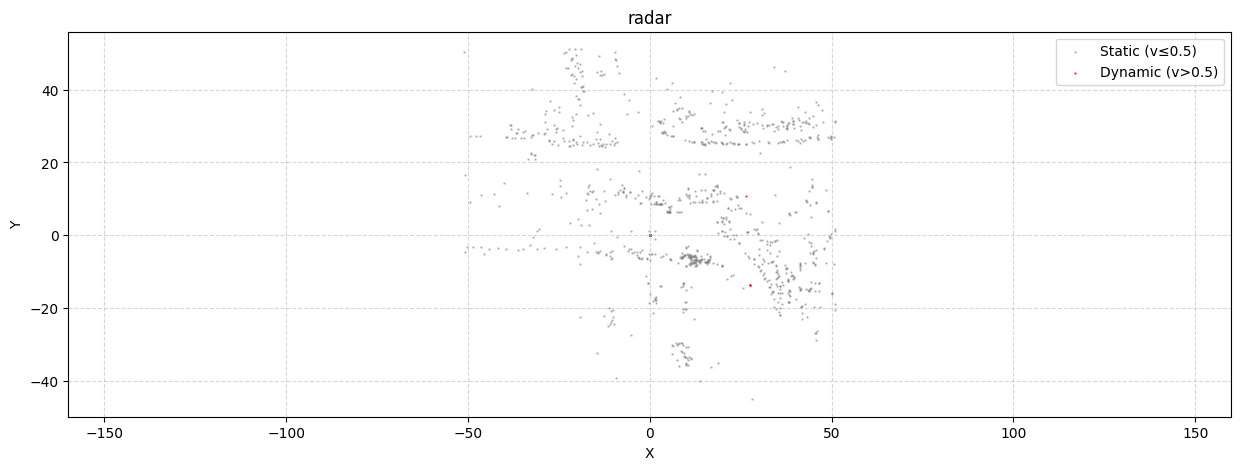

resuming by loading epoch 30
Model has 8114886.0 trainable parameters.


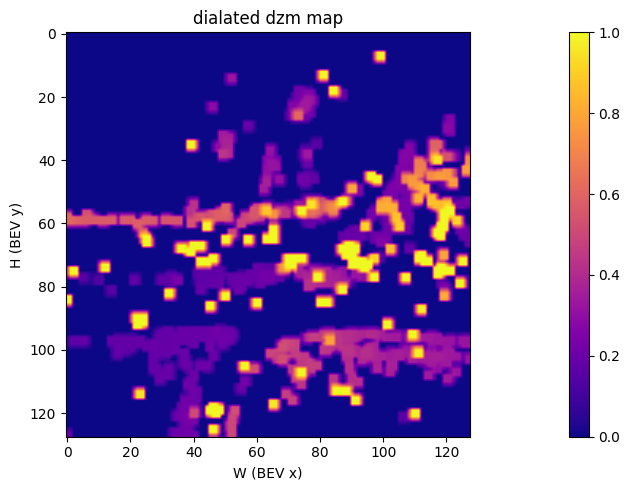

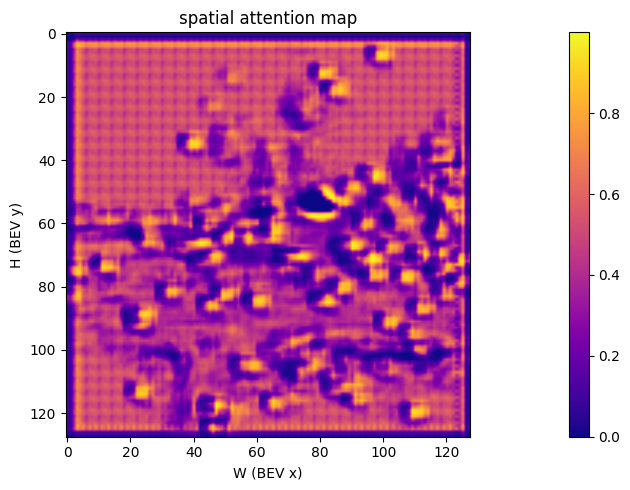

In [30]:

import torch
import numpy as np
from opencood.hypes_yaml.yaml_utils import load_yaml
from opencood.tools import train_utils
from opencood.data_utils.datasets import build_dataset
import torch
def move_to_device(data, device):
    if isinstance(data, torch.Tensor):
        return data.to(device)
    elif isinstance(data, dict):
        return {k: move_to_device(v, device) for k, v in data.items()}
    elif isinstance(data, list):
        return [move_to_device(x, device) for x in data]
    else:
        return data



if inference:
    hypes = load_yaml("/home/ws-ids-es3-01/PycharmProjects/hamdard_bm2cp/opencood/logs/paper_inference_with_other_epochs/pointpillar_single_lidar_radar_baseline_attention_mlp_2025_09_15_03_17_56/config.yaml")

    # print('Dataset Building')
    dataset = SingleDatasetLidarRadarBaselineAttentionMlp(hypes, visualize=False)
    batch_list = [dataset[90]]
    batch = dataset.collate_batch_test(batch_list)

    # print('Creating Model')
    model = PointPillarSingleLidarRadarBaselineAttentionMlpHis(hypes['model']['args'])
    # we assume gpu is necessary
    if torch.cuda.is_available():
        model.cuda()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # print('Loading Model from checkpoint')
    saved_path = "/home/ws-ids-es3-01/PycharmProjects/hamdard_bm2cp/opencood/logs/paper_inference_with_other_epochs/pointpillar_single_lidar_radar_baseline_attention_mlp_2025_09_15_03_17_56"
    _, model = train_utils.load_saved_model(saved_path, model)
    model.eval()
    model_parameters = filter(lambda p: p.requires_grad, model.parameters())
    params = sum([np.prod(p.size()) for p in model_parameters])
    print(f"Model has {params} trainable parameters.")
    # Create the dictionary for evaluation.
    # also store the confidence score for each prediction
    with torch.no_grad():
        batch = train_utils.to_device(batch, device)
        output = model(batch['ego'])
else: 
    # === load data config ===
    yaml_path = "/home/nj644_local/koglabor2425/OpenCOOD/opencood/hypes_yaml/interf_multiscale_deform_v2.yaml"
    params = load_yaml(yaml_path)
    dataset = SingleDatasetLidarRadarBaselineAttentionMlp(params, visualize=False)

    # === select one data frame ===
    sample_id = 230
    batch = [dataset[sample_id]]
    data_dict = dataset.collate_batch_train(batch)

    # === prepare the model ===
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = PointPillarSingleLidarRadarBaselineAttentionMlpHis(params['model']['args']).to(device)
    data_dict = move_to_device(data_dict['ego'], device)
    output = model(data_dict)

